# Understanding data

This notebook is dedicated to understanding the data provided.

In [1]:
from pathlib import Path

data_dir = Path('../input/jane-street-real-time-market-data-forecasting')

## Step 1: Loading training

Let's spend sometime understanding how the training set is structured.

In [2]:
import pandas as pd

for partition in range(0, 10):
    location = data_dir / f'train.parquet/partition_id={partition}/part-0.parquet'
    df = pd.read_parquet(location, columns=['date_id'])
    min_date, max_date = df['date_id'].min(), df['date_id'].max()
    print(f"Partition {partition}:")
    print(f"\tMin = {min_date}")
    print(f"\tMax = {max_date}")
    print('=' * 120)

Partition 0:
	Min = 0
	Max = 169
Partition 1:
	Min = 170
	Max = 339
Partition 2:
	Min = 340
	Max = 509
Partition 3:
	Min = 510
	Max = 679
Partition 4:
	Min = 680
	Max = 849
Partition 5:
	Min = 850
	Max = 1019
Partition 6:
	Min = 1020
	Max = 1189
Partition 7:
	Min = 1190
	Max = 1359
Partition 8:
	Min = 1360
	Max = 1529
Partition 9:
	Min = 1530
	Max = 1698


These results indicate that there is no overlap in dates between partitions, and that they follow a chronological ordering. 

Let's then investigate some of the details only for partition 0.

In [3]:
train_0 = pd.read_parquet(data_dir / 'train.parquet/partition_id=0/part-0.parquet')

train_0.sort_values(by=['date_id', 'time_id'], inplace=True)

## Step 2: Quick overlook on `responder_6`

Let's see if there is any considerable shift in the responder as a function of date.

In [4]:
daily = train_0.groupby('date_id')
r6_daily_avg = daily['responder_6'].mean()
r6_daily_std = daily['responder_6'].std()

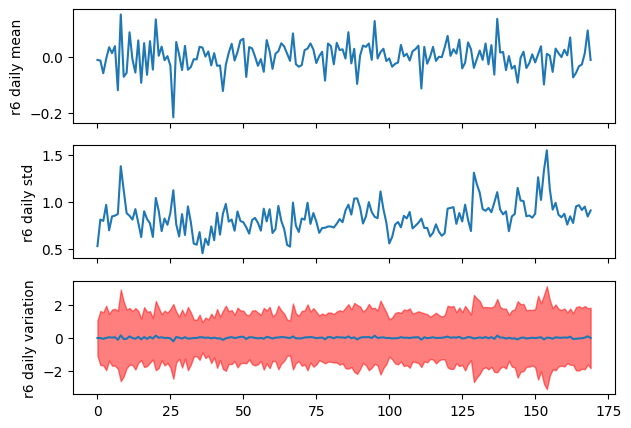

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, sharex='col', figsize=(7, 5))
axes[0].set_ylabel('r6 daily mean')
axes[1].set_ylabel('r6 daily std')
axes[2].set_ylabel('r6 daily variation')

axes[0].plot(r6_daily_avg)
axes[1].plot(r6_daily_std)
_ = axes[-1].fill_between(range(len(r6_daily_avg)),
                          r6_daily_avg + 2 * r6_daily_std,
                          r6_daily_avg - 2 * r6_daily_std,
                          color='red',
                          alpha=0.5)
_ = axes[-1].plot(r6_daily_avg)

## Step 3: Quick check on features

Now, let's take a look at some other statistics

In [6]:
# assuming df is partition 0
print("Dates:", train_0["date_id"].nunique())
print("Time per date:")
print(train_0.groupby("date_id")["time_id"].nunique().describe())

print("Symbols per timestep:")
print(train_0.groupby(["date_id","time_id"])["symbol_id"].nunique().describe())

print("Feature stats (first 10 features):")
print(train_0[[f"feature_{i:02d}" for i in range(10)]].describe())

print("Target stats:")
print(train_0["responder_6"].describe())

print("Weight stats:")
print(train_0["weight"].describe())

Dates: 170
Time per date:
count    170.0
mean     849.0
std        0.0
min      849.0
25%      849.0
50%      849.0
75%      849.0
max      849.0
Name: time_id, dtype: float64
Symbols per timestep:
count    144330.000000
mean         13.470588
std           3.252479
min           4.000000
25%          11.000000
50%          13.500000
75%          16.000000
max          20.000000
Name: symbol_id, dtype: float64
Feature stats (first 10 features):
       feature_00  feature_01  feature_02  feature_03  feature_04  \
count         0.0         0.0         0.0         0.0         0.0   
mean          NaN         NaN         NaN         NaN         NaN   
std           NaN         NaN         NaN         NaN         NaN   
min           NaN         NaN         NaN         NaN         NaN   
25%           NaN         NaN         NaN         NaN         NaN   
50%           NaN         NaN         NaN         NaN         NaN   
75%           NaN         NaN         NaN         NaN         NaN   

It appears some features are all `NaN`. Let's get a better understanding of how often we have missing information.

In [7]:
# list of all feature columns
feature_cols = [f"feature_{i:02d}" for i in range(79)]

# compute fraction of NaNs per feature
nan_fraction_per_feature = train_0[feature_cols].isna().mean()

# display nicely
for feature, frac in nan_fraction_per_feature.items():
    print(f"{feature}: {frac*100:.1f}%")

feature_00: 100.0%
feature_01: 100.0%
feature_02: 100.0%
feature_03: 100.0%
feature_04: 100.0%
feature_05: 0.0%
feature_06: 0.0%
feature_07: 0.0%
feature_08: 0.9%
feature_09: 0.0%
feature_10: 0.0%
feature_11: 0.0%
feature_12: 0.0%
feature_13: 0.0%
feature_14: 0.0%
feature_15: 2.8%
feature_16: 0.0%
feature_17: 0.5%
feature_18: 0.0%
feature_19: 0.0%
feature_20: 0.0%
feature_21: 100.0%
feature_22: 0.0%
feature_23: 0.0%
feature_24: 0.0%
feature_25: 0.0%
feature_26: 100.0%
feature_27: 100.0%
feature_28: 0.0%
feature_29: 0.0%
feature_30: 0.0%
feature_31: 100.0%
feature_32: 1.1%
feature_33: 1.1%
feature_34: 0.0%
feature_35: 0.0%
feature_36: 0.0%
feature_37: 0.0%
feature_38: 0.0%
feature_39: 16.7%
feature_40: 2.0%
feature_41: 5.0%
feature_42: 16.7%
feature_43: 2.0%
feature_44: 5.0%
feature_45: 8.6%
feature_46: 8.6%
feature_47: 0.0%
feature_48: 0.0%
feature_49: 0.0%
feature_50: 15.1%
feature_51: 0.1%
feature_52: 3.3%
feature_53: 15.1%
feature_54: 0.1%
feature_55: 3.3%
feature_56: 0.0%
feature_5

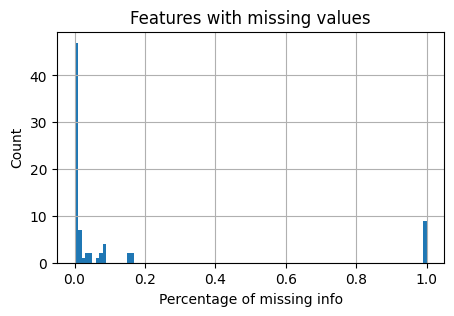

In [8]:
import numpy as np

axes = nan_fraction_per_feature.hist(bins=np.arange(0., 1.01, 0.01).tolist())
axes.set_ylabel('Count')
axes.set_xlabel('Percentage of missing info')
axes.set_title('Features with missing values')

fig = axes.get_figure()
fig.set_size_inches(5, 3)

As we can see, there are a number of features with missing information. In particular, they appear to be in one of four categories:
- fully missing (can be discarded)
- ~15% of entries missing (needs imputation and possibly a missing-value flag)
- ~8% of entries missing (needs imputation and possibly missing-value flag)
- <5% missing entries (needs imputation, likely ok without missing-value flag)

## Step 4: Understand responder dynamics based on symbol

### Step 4.1: Look at total `symbol_id` counts

Let's first see how many different symbols we have, and how many of each.

In [9]:
symbol_counts = train_0["symbol_id"].value_counts()

In [10]:
print(symbol_counts.describe())

count        20.000000
mean      97210.500000
std       41222.655494
min       20376.000000
25%       60915.750000
50%      109521.000000
75%      138387.000000
max      143481.000000
Name: count, dtype: float64


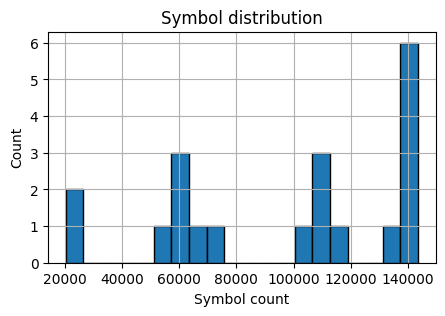

In [11]:
axes = symbol_counts.hist(bins=20, edgecolor='k')
axes.set_ylabel('Count')
axes.set_xlabel('Symbol count')
axes.set_title('Symbol distribution')

fig = axes.get_figure()
fig.set_size_inches(5, 3)

We can see that symbols appear at varying rates, but even with 20k responses, we should have enough for modeling.

### Step 4.2: Responder distribution by symbol

Let's now evaluate how the distribution of the responder varies by symbol.

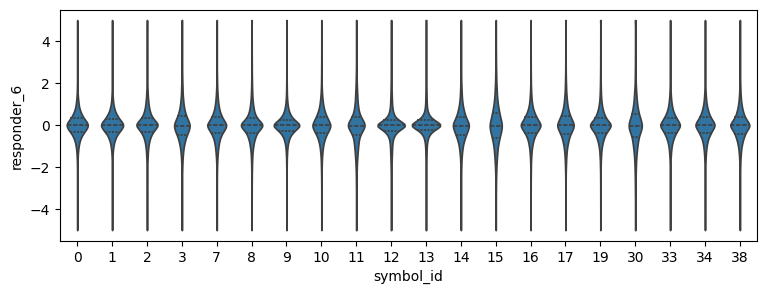

In [12]:
import seaborn as sns

axes = sns.violinplot(data=train_0, x='symbol_id', y='responder_6',
                      inner='quart',
                      # bw_adjust=0.5,
                      # native_scale=True,
                      cut=0)

fig = axes.get_figure()
fig.set_figheight(3)
fig.set_figwidth(9)

It appears that these distributions are somewhat different... Let's see if we can zoom-in a bit where the data is concentrated

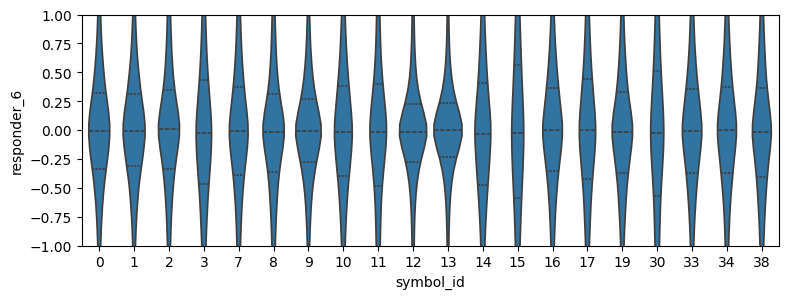

In [13]:
axes.set_ylim([-1, 1])
axes.get_figure()

Indeed, we see that some of these are skinnier, while some are more concentrated around the mean. 

In [14]:
symbol_stats = train_0.groupby("symbol_id")["responder_6"].agg(
    ["mean", "std", "min", "max", "count"]
)

In [15]:
symbol_stats.describe()

,mean,std,min,max,count
count,20.000000,20.000000,20.0,20.0,20.000000
mean,0.001055,0.914534,-5.0,5.0,97210.500000
std,0.018717,0.176516,0.0,0.0,41222.655494
min,-0.034786,0.635928,-5.0,5.0,20376.000000
25%,-0.006809,0.794752,-5.0,5.0,60915.750000
50%,0.000701,0.886654,-5.0,5.0,109521.000000
75%,0.007750,1.008108,-5.0,5.0,138387.000000
max,0.036099,1.323042,-5.0,5.0,143481.000000


## Step 4.3: Evaluating correlations in responder

Let's now see if there are correlations in the responder based on the symbols.

Since there are many dates in just a single partition, it is unlikely for the responder values at the last date to be correlated with the ones on the first one, even for the same symbol. Therefore we will instead only look at intra-day correlations

In [16]:
# Choose a random date
random_date = train_0['date_id'].sample(n=1, random_state=1234).to_list()[0]
print(f'Chosen data = {random_date}')

Chosen data = 37


In [17]:
# Get that date's data
random_date_data = train_0[train_0['date_id'] == random_date]

# Pivot and compute correlation
pivot = random_date_data.pivot_table(
    index="time_id",
    columns="symbol_id",
    values="responder_6"
    )

correlation = pivot.corr()

In [18]:
correlation

symbol_id,0,1,2,3,7,9,13,16,19,33,38
symbol_id,,,,,,,,,,,
0,1.000000,0.439032,-0.228799,0.318823,0.277324,0.284603,0.190197,0.330629,0.164366,0.308334,0.106970
1,0.439032,1.000000,-0.396678,0.426813,0.380901,0.263454,0.389587,0.208149,0.381564,0.352265,0.016269
2,-0.228799,-0.396678,1.000000,-0.070826,-0.072216,0.064639,-0.275863,-0.320018,-0.055714,-0.110584,-0.024986
3,0.318823,0.426813,-0.070826,1.000000,0.320369,0.422194,0.035281,0.264556,0.287497,0.316767,0.102037
7,0.277324,0.380901,-0.072216,0.320369,1.000000,0.362528,-0.015589,0.175367,0.380234,0.351679,0.144171
9,0.284603,0.263454,0.064639,0.422194,0.362528,1.000000,-0.210579,0.066362,0.173579,0.346470,0.131103
13,0.190197,0.389587,-0.275863,0.035281,-0.015589,-0.210579,1.000000,0.019336,-0.031364,-0.002599,-0.066807
16,0.330629,0.208149,-0.320018,0.264556,0.175367,0.066362,0.019336,1.000000,0.186139,0.264391,0.077736
19,0.164366,0.381564,-0.055714,0.287497,0.380234,0.173579,-0.031364,0.186139,1.000000,0.238567,0.064128


Max cross-correlation found = 0.43903173258193356


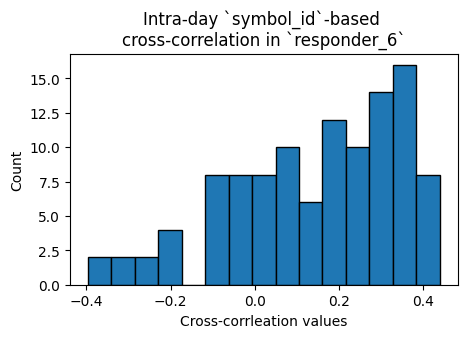

In [19]:
corr_matrix = correlation.to_numpy()

print(f'Max cross-correlation found = {max(abs(corr_matrix[corr_matrix != 1.]))}')

fig, axes = plt.subplots(1, 1, figsize=(5, 3))
axes.set_xlabel('Cross-corrleation values')
axes.set_ylabel('Count')
axes.set_title('Intra-day `symbol_id`-based \ncross-correlation in `responder_6`')
_ = axes.hist(corr_matrix[corr_matrix != 1.].flatten(),
              bins=15,
              edgecolor='k')

### Step 4.4: Autocorrelation in `responder_6` based on `symbol_id`

Let's now evaluate the rolling autocorrelation in `responder_6`

Note that here, since the `'time_id'` entries are no uniformly distributed and not guaranteed to appear in the same amount on the same date, we will simply use an order-based autocorrelation, rather than time-based one.

In [20]:
import numpy as np

def compute_autocorr(x, lag=1):
    if len(x) <= lag:
        return np.nan
    return np.corrcoef(x[:-lag], x[lag:])[0, 1]


symbols = train_0["symbol_id"].unique().tolist()
symbols_autocorr = dict.fromkeys(symbols)

for s in symbols:
    # Create entry
    symbols_autocorr[s] = []

    # Get relevant data
    sub = train_0[train_0["symbol_id"] == s].sort_values(
        ["date_id", "time_id"])["responder_6"].values

    # Compute autocorr
    for lag in range(1, 100):
        symbols_autocorr[s].append(compute_autocorr(sub, lag=lag))

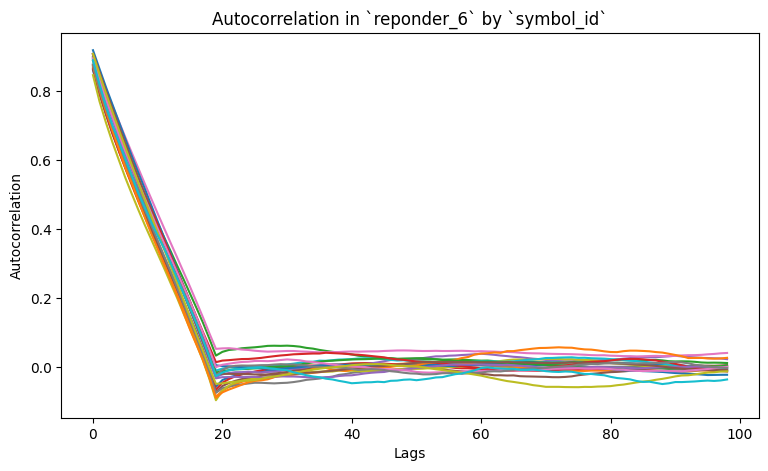

In [21]:
fig, axes = plt.subplots(1, 1, figsize=(9, 5))
axes.set_xlabel('Lags')
axes.set_ylabel('Autocorrelation')
axes.set_title('Autocorrelation in `reponder_6` by `symbol_id`')

for symbol, autocorr in symbols_autocorr.items():
    axes.plot(autocorr, label=symbol)

# _ = axes.legend(loc='upper right')

## Step 5: Explore correlations between responders